# E-Commerce Sales Analysis

This Dashboard gives a clear view of how sales are performing across platforms 
like Jiomart,Swiggy_instamart and Blinkit.
It helps track Customer orders,delivery performance,ratings,refunds and overall revenue.

This helps in many Questions like,
- Which Platform has the most orders
- How many deliveries were delayed
- How many refunds were requested
- Average order value and customer rating

In [3]:
# Importin libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Read File
df = pd.read_excel("Ecommerce_Delivery_Analytics_New.xlsx")

In [5]:
# Few rows
df.head()

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No


In [6]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Order ID                 100000 non-null  object
 1   Customer ID              100000 non-null  object
 2   Platform                 100000 non-null  object
 3   Order Date & Time        100000 non-null  object
 4   Delivery Time (Minutes)  100000 non-null  int64 
 5   Product Category         100000 non-null  object
 6   Order Value (INR)        100000 non-null  int64 
 7   Customer Feedback        100000 non-null  object
 8   Service Rating           100000 non-null  int64 
 9   Delivery Delay           100000 non-null  object
 10  Refund Requested         100000 non-null  object
dtypes: int64(3), object(8)
memory usage: 8.4+ MB


In [7]:
df.shape

(100000, 11)

In [8]:
#Checking null values
df.isnull().sum()

Order ID                   0
Customer ID                0
Platform                   0
Order Date & Time          0
Delivery Time (Minutes)    0
Product Category           0
Order Value (INR)          0
Customer Feedback          0
Service Rating             0
Delivery Delay             0
Refund Requested           0
dtype: int64

In [9]:
# Convert coulmns name into lowercase with _
df.columns = df.columns.str.strip().str.lower().str.replace(' ',"_")
df.columns

Index(['order_id', 'customer_id', 'platform', 'order_date_&_time',
       'delivery_time_(minutes)', 'product_category', 'order_value_(inr)',
       'customer_feedback', 'service_rating', 'delivery_delay',
       'refund_requested'],
      dtype='object')

In [10]:
# Drop column
df.drop(columns='order_id',inplace=True)

In [11]:
# Convert into Numerical values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['customer_id'] = le.fit_transform(df['customer_id'])

In [12]:
df.head()

,customer_id,platform,order_date_&_time,delivery_time_(minutes),product_category,order_value_(inr),customer_feedback,service_rating,delivery_delay,refund_requested
0,1824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,4506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,4012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,3657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No


In [13]:
# uniques values and their shape
df['customer_id'].unique().shape

(9000,)

In [14]:
# Randomly check
df[df['customer_id']==1824]

,customer_id,platform,order_date_&_time,delivery_time_(minutes),product_category,order_value_(inr),customer_feedback,service_rating,delivery_delay,refund_requested
0,1824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
8872,1824,Swiggy Instamart,35:29.5,34,Grocery,258,Excellent experience!,5,No,No
13634,1824,Blinkit,14:29.5,32,Grocery,1035,Quick and reliable!,5,No,No
47989,1824,JioMart,56:29.5,18,Grocery,1378,Wrong item delivered.,1,No,Yes
58190,1824,Swiggy Instamart,58:29.5,22,Dairy,389,Items missing from order.,2,No,Yes
80452,1824,Swiggy Instamart,01:29.5,27,Dairy,233,"Fast delivery, great service!",5,No,No
82736,1824,Blinkit,42:29.5,10,Beverages,398,Excellent experience!,5,No,No
87634,1824,JioMart,55:29.5,30,Dairy,123,Quick and reliable!,5,No,No


In [15]:
df['platform'].unique()

array(['JioMart', 'Blinkit', 'Swiggy Instamart'], dtype=object)

In [16]:
# Convert platform names into lower case with _
df['platform'] = df['platform'].str.strip().str.lower().str.replace(' ','_')

In [17]:
df['platform'].unique()

array(['jiomart', 'blinkit', 'swiggy_instamart'], dtype=object)

In [18]:
# Time extract
from datetime import datetime
def time(t):
    try:
        return datetime.strptime(t,"%M:%S.%f").time()
    except ValueError:
        return None
df['order_time'] =df["order_date_&_time"].apply(time)

In [19]:
df.drop(columns='order_date_&_time',inplace=True)

In [20]:
df.head()

,customer_id,platform,delivery_time_(minutes),product_category,order_value_(inr),customer_feedback,service_rating,delivery_delay,refund_requested,order_time
0,1824,jiomart,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No,00:19:29.500000
1,409,blinkit,16,Dairy,279,Quick and reliable!,5,No,No,00:54:29.500000
2,4506,jiomart,25,Beverages,599,Items missing from order.,2,No,Yes,00:21:29.500000
3,4012,jiomart,42,Beverages,946,Items missing from order.,2,Yes,Yes,00:19:29.500000
4,3657,blinkit,30,Beverages,334,"Fast delivery, great service!",5,No,No,00:49:29.500000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   customer_id              100000 non-null  int32 
 1   platform                 100000 non-null  object
 2   delivery_time_(minutes)  100000 non-null  int64 
 3   product_category         100000 non-null  object
 4   order_value_(inr)        100000 non-null  int64 
 5   customer_feedback        100000 non-null  object
 6   service_rating           100000 non-null  int64 
 7   delivery_delay           100000 non-null  object
 8   refund_requested         100000 non-null  object
 9   order_time               100000 non-null  object
dtypes: int32(1), int64(3), object(6)
memory usage: 7.2+ MB


In [22]:
df['product_category'].unique()

array(['Fruits & Vegetables', 'Dairy', 'Beverages', 'Personal Care',
       'Grocery', 'Snacks'], dtype=object)

In [23]:
df['product_category'] = df['product_category'].str.strip().str.lower().str.replace(' ','_')

In [24]:
df['product_category'].unique()

array(['fruits_&_vegetables', 'dairy', 'beverages', 'personal_care',
       'grocery', 'snacks'], dtype=object)

In [25]:
positive_keywords = ['good','excellent','amazing','awesome','perfect','nice','love','best','satisfied','great','worth','fantastic','happy','useful','recommend','comfortable','affordable','reliable','brilliant','liked']
negitive_keywords = ['bad','poor','worst','disappointed','waste','terrible','hate','broken','cheap','problem','issue','damaged','unhappy','delay','uncomfortable','not working',"doesn't working",'fake','low quality']

In [26]:
# Set category
def check(text):
    text = str(text).lower()
    pos = sum(1 for word in positive_keywords if word in text)
    neg = sum(1 for word in negitive_keywords if word in text)

    if pos > neg:
        return 'Positive'
    elif neg > pos:
        return "Negitive"
        
    elif pos==0 and neg==0:
        return 'Neutral'
    else:
        return 'Neutral'

df['feedback_category'] = df['customer_feedback'].apply(check)

In [27]:
df.head()

,customer_id,platform,delivery_time_(minutes),product_category,order_value_(inr),customer_feedback,service_rating,delivery_delay,refund_requested,order_time,feedback_category
0,1824,jiomart,30,fruits_&_vegetables,382,"Fast delivery, great service!",5,No,No,00:19:29.500000,Positive
1,409,blinkit,16,dairy,279,Quick and reliable!,5,No,No,00:54:29.500000,Positive
2,4506,jiomart,25,beverages,599,Items missing from order.,2,No,Yes,00:21:29.500000,Neutral
3,4012,jiomart,42,beverages,946,Items missing from order.,2,Yes,Yes,00:19:29.500000,Neutral
4,3657,blinkit,30,beverages,334,"Fast delivery, great service!",5,No,No,00:49:29.500000,Positive


In [109]:
df[df['feedback_category']=="Negitive"].head(3)

,customer_id,platform,delivery_time_(minutes),product_category,order_value_(inr),customer_feedback,service_rating,delivery_delay,refund_requested,order_time,feedback_category,refund_numeric,delivery_delay_numeric
16,434,swiggy_instamart,41,beverages,956,"Not fresh, disappointed.",2,Yes,Yes,00:58:29.500000,Negitive,1,1
53,1654,blinkit,20,fruits_&_vegetables,424,"Not fresh, disappointed.",2,No,Yes,00:29:29.500000,Negitive,1,0
58,2664,jiomart,27,dairy,557,"Not fresh, disappointed.",2,No,Yes,00:49:29.500000,Negitive,1,0


In [29]:
# Mapping values into numerical form
df['refund_numeric'] = df['refund_requested'].map({'Yes':1,'No':0})

In [30]:
df['delivery_delay_numeric'] = df['delivery_delay'].map({'Yes':1,'No':0})

In [31]:
df.head()

,customer_id,platform,delivery_time_(minutes),product_category,order_value_(inr),customer_feedback,service_rating,delivery_delay,refund_requested,order_time,feedback_category,refund_numeric,delivery_delay_numeric
0,1824,jiomart,30,fruits_&_vegetables,382,"Fast delivery, great service!",5,No,No,00:19:29.500000,Positive,0,0
1,409,blinkit,16,dairy,279,Quick and reliable!,5,No,No,00:54:29.500000,Positive,0,0
2,4506,jiomart,25,beverages,599,Items missing from order.,2,No,Yes,00:21:29.500000,Neutral,1,0
3,4012,jiomart,42,beverages,946,Items missing from order.,2,Yes,Yes,00:19:29.500000,Neutral,1,1
4,3657,blinkit,30,beverages,334,"Fast delivery, great service!",5,No,No,00:49:29.500000,Positive,0,0


In [32]:
df['service_rating'].unique()

array([5, 2, 1, 4, 3], dtype=int64)

customer_id
3519    22
4476    22
4009    22
1633    23
2532    23
2001    23
4902    23
7289    24
848     25
7779    26
Name: count, dtype: int64


C:\Users\karan\AppData\Local\Temp\ipykernel_11848\1045636536.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.index,y=top_customers.values,order=top_customers.index,palette='dark')


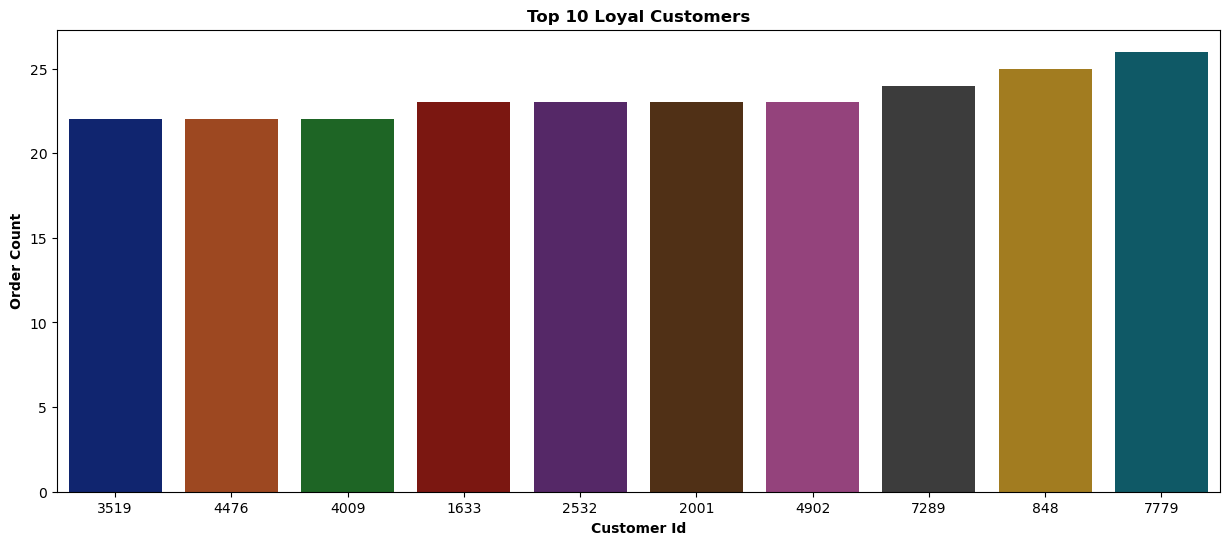

In [81]:
top_customers = df['customer_id'].value_counts().head(10)
top_customers = top_customers.sort_values(ascending=True)
plt.figure(figsize=(15,6))

print(top_customers)

sns.barplot(x=top_customers.index,y=top_customers.values,order=top_customers.index,palette='dark')
plt.title("Top 10 Loyal Customers",fontweight = 'bold')
plt.xlabel("Customer Id",fontweight = 'bold')
plt.ylabel("Order Count",fontweight = 'bold')
plt.show()

Text(0, 0.5, 'Refund Rate')

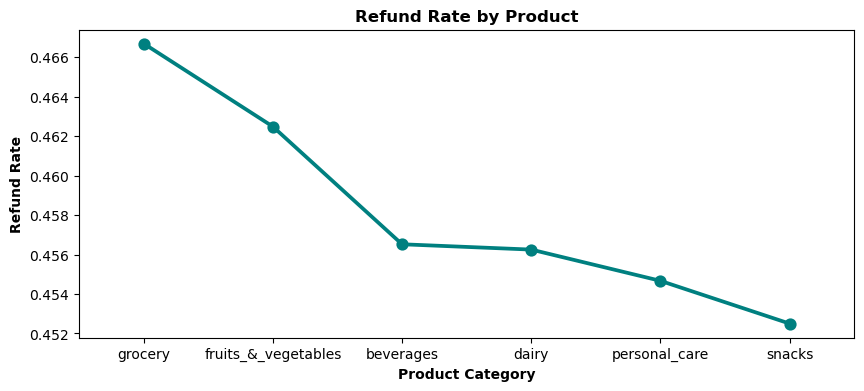

In [83]:
refund=df.groupby("product_category")['refund_requested'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False)
plt.figure(figsize=(10,4))
sns.pointplot(x=refund.index,y=refund.values,color='teal')
plt.title("Refund Rate by Product",fontweight = 'bold')
plt.xlabel("Product Category",fontweight = 'bold')
plt.ylabel("Refund Rate",fontweight = 'bold')

In [52]:
platform_wise_order = df.groupby('platform')['order_value_(inr)'].mean()

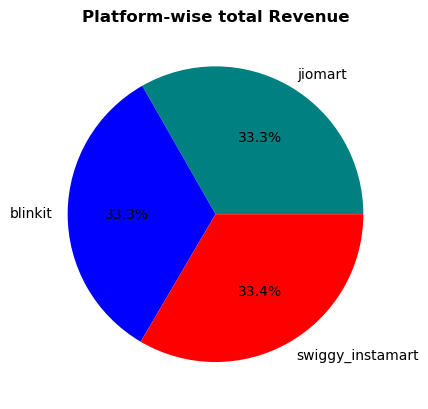

In [85]:
labels = df['platform'].unique()
colors = ['Teal',"Blue",'Red']
plt.pie(platform_wise_order,labels=labels,autopct='%1.1f%%',colors=colors)
plt.title("Platform-wise total Revenue",fontweight = 'bold')
plt.show()

In [56]:
category_wise_order=df.groupby("product_category")['order_value_(inr)'].mean()
category_wise_order

product_category
beverages               549.508285
dairy                   451.475470
fruits_&_vegetables     375.572210
grocery                 848.064468
personal_care          1052.174499
snacks                  273.335887
Name: order_value_(inr), dtype: float64

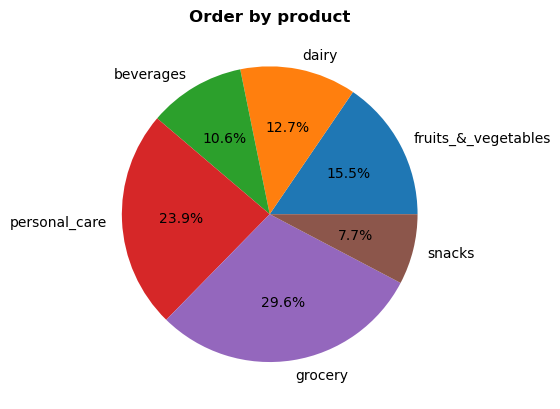

In [89]:
labels = df['product_category'].unique()
plt.pie(category_wise_order,labels=labels,autopct='%1.1f%%')
plt.title("Order by product",fontweight = 'bold')
plt.show()

In [95]:
refund = df.groupby('platform')['refund_numeric'].sum()

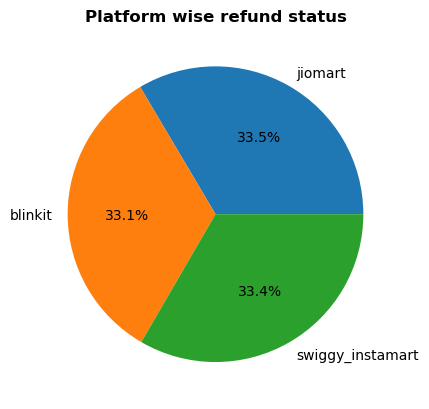

In [99]:
labels = df['platform'].unique()
plt.pie(refund,labels=labels,autopct='%1.1f%%')
plt.title("Platform wise refund status",fontweight = 'bold')
plt.show()

<Axes: xlabel='order_value_(inr)', ylabel='delivery_delay_numeric'>

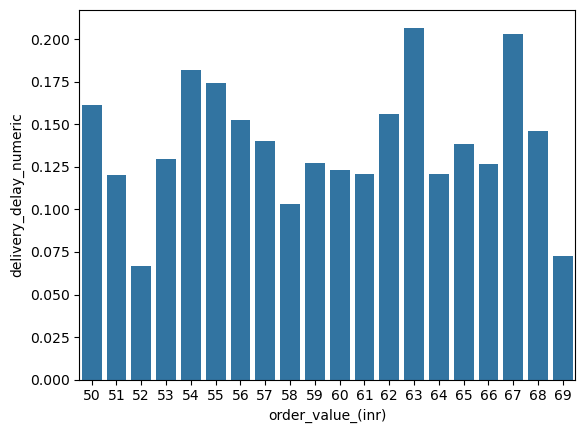

In [103]:
DBV = df.groupby('order_value_(inr)')['delivery_delay_numeric'].mean().reset_index().head(20)
sns.barplot(data=DBV,x='order_value_(inr)',y='delivery_delay_numeric')

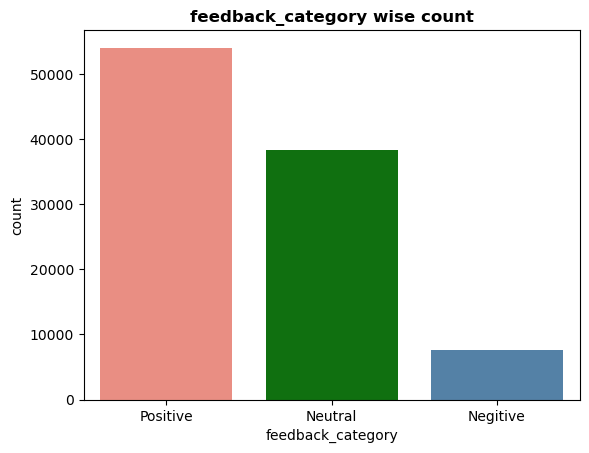

In [105]:
color = {'Positive': 'salmon', 'Negitive': 'steelblue',"Neutral":'green'}

sns.countplot(x='feedback_category',data=df,palette=color,hue='feedback_category')
plt.title("feedback_category wise count",fontweight = 'bold')
plt.show()


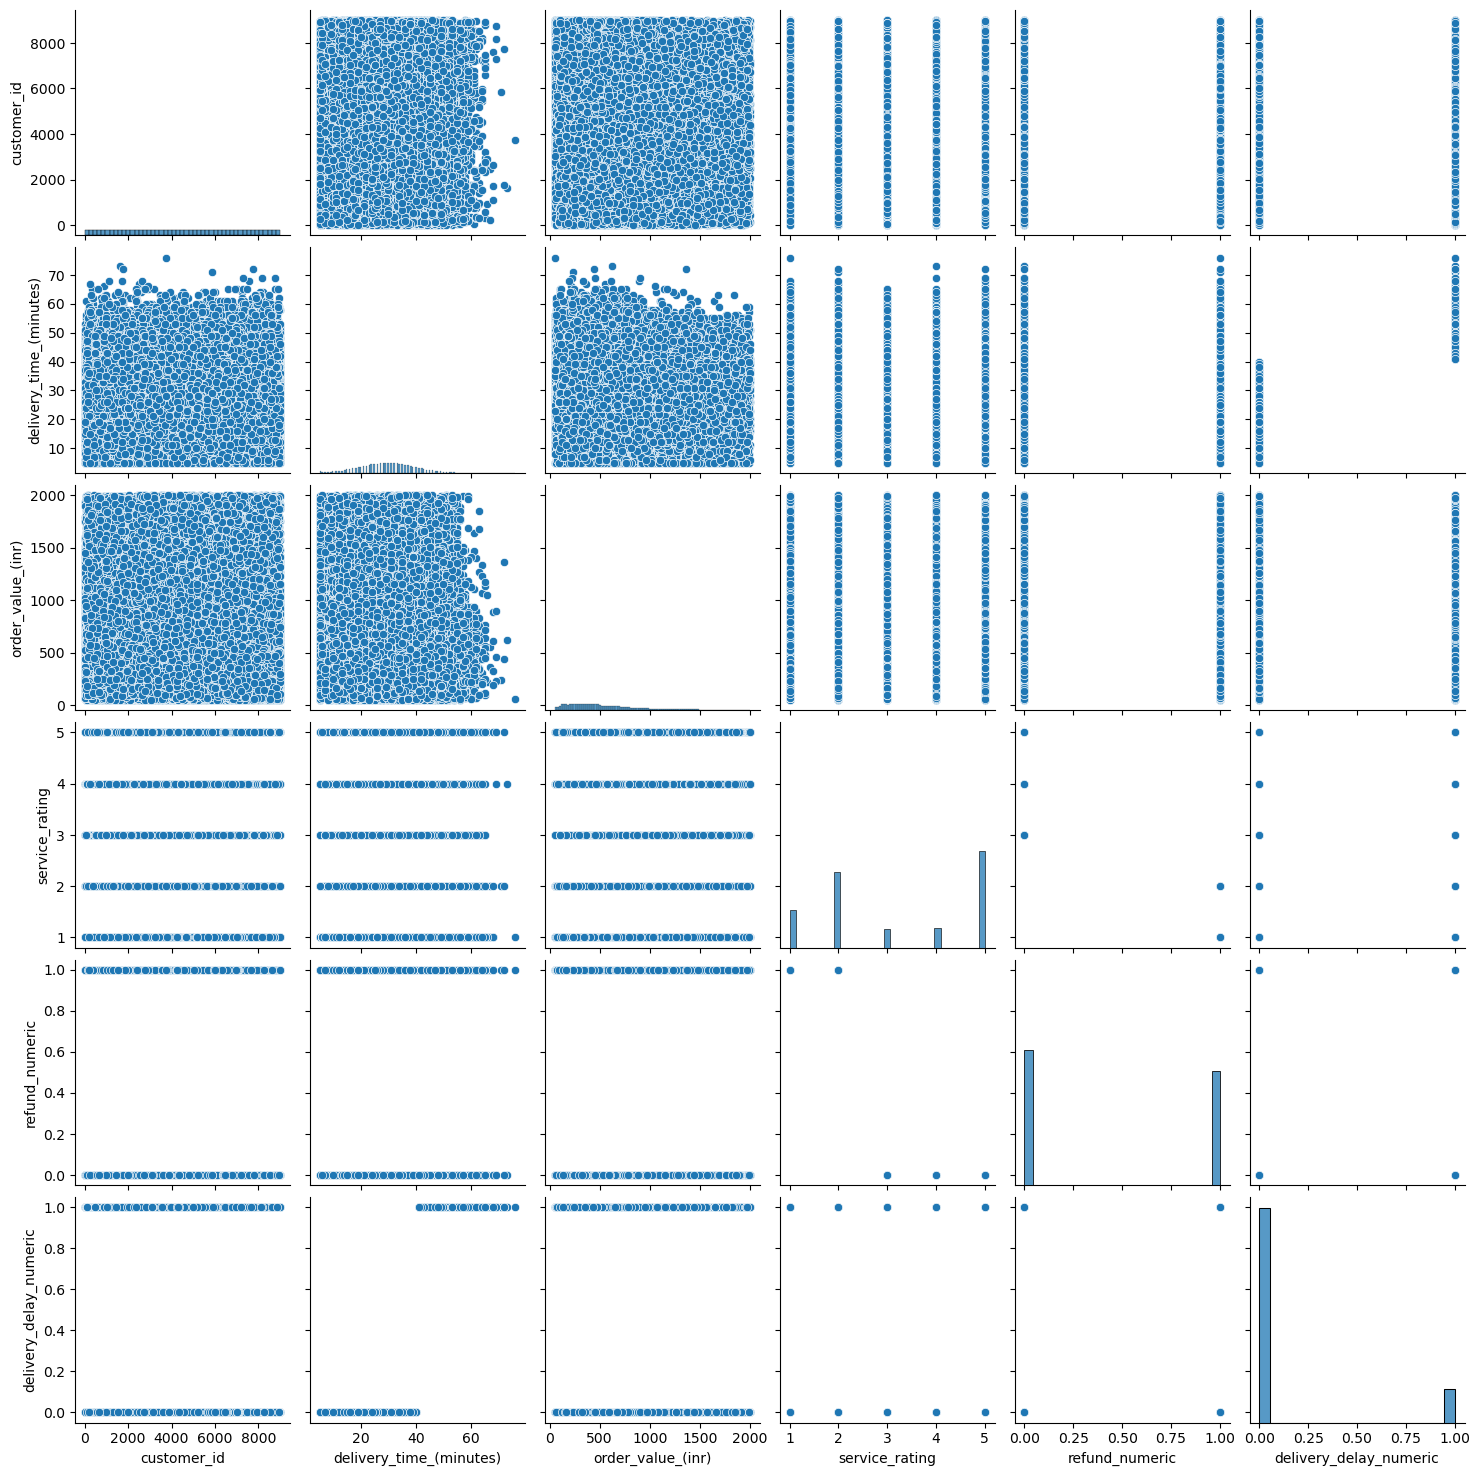

In [68]:
sns.pairplot(df)

Text(0.5, 1.0, 'Feedback category')

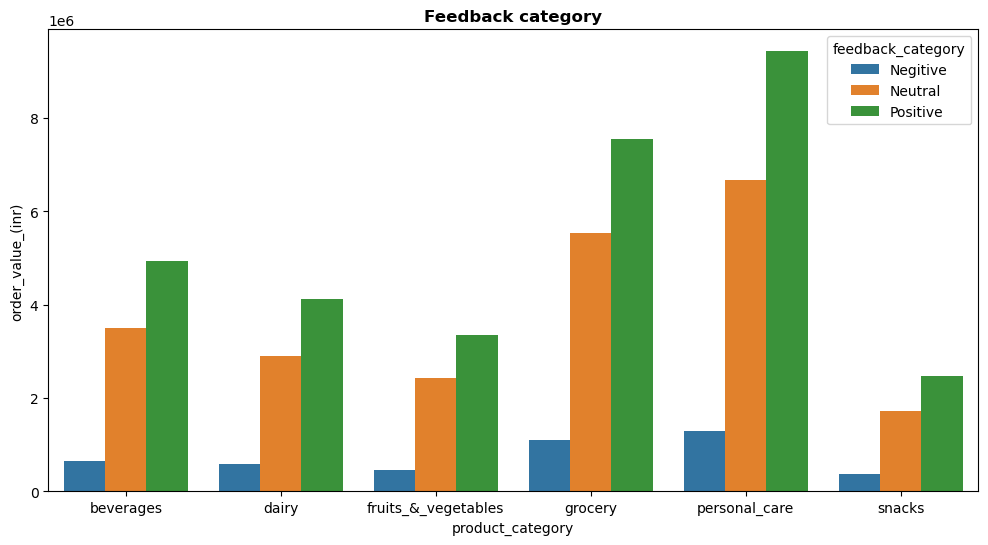

In [107]:
group = df.groupby(['product_category','feedback_category'])['order_value_(inr)'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=group,x='product_category',y='order_value_(inr)',hue="feedback_category")
plt.title("Feedback category",fontweight = 'bold')

In [70]:
df.to_csv("Ecommerce_sales_analysis_updated.csv",index=False)

# Thank You...